# MediciMess Phase 8 — Forensic Analysis

## 1. Phase 8 Objective

This notebook uses the completed ingestion pipeline and the existing Phase 4 anomaly engine to identify the expense supplier associated with the highest number of **distinct** anomaly rules. It then traces alert transaction IDs back to the validated ledger, deduplicates those IDs, quantifies the activity with `Decimal`, and recommends controls.

The analysis does **not** search for a predetermined supplier and does not rebuild Rules A–G. Because some rules operate at group level and use `counterparty=None`, supplier attribution is performed through `affected_transaction_ids`. A supplier is defined as a counterparty on an `operating_expense` transaction.

## 2. Imports and Data Loading

In [1]:
from collections import Counter, defaultdict
from decimal import Decimal
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "medici_transactions.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from analytics.alerts import generate_alerts
from ingestion.pipeline import run_pipeline

DATA_PATH = PROJECT_ROOT / "medici_transactions.csv"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: /Users/hakeem/Projects/MediciMess_Charlie
Dataset: /Users/hakeem/Projects/MediciMess_Charlie/medici_transactions.csv


## 3. Run Validation Pipeline

The shared ingestion pipeline performs CSV normalization and passes each transaction through the shared validator. The published baseline is 80,230 accepted transactions.

In [2]:
ingestion_result = run_pipeline(DATA_PATH)
transactions = ingestion_result.accepted

assert ingestion_result.total_records == 80_230
assert ingestion_result.accepted_count == 80_230
assert ingestion_result.rejected_count == 0
assert not ingestion_result.source_errors

transactions_by_id = {transaction["id"]: transaction for transaction in transactions}
print(f"Validated transactions: {len(transactions):,}")

=== Pipeline Summary ===
Source file:      /Users/hakeem/Projects/MediciMess_Charlie/medici_transactions.csv
Total records:    80230
Accepted:         80230
Rejected:         0
Skipped:          0
Validated transactions: 80,230


## 4. Generate Phase 4 Alerts

`generate_alerts()` is reused directly. No anomaly rule is reimplemented in this notebook.

In [3]:
alerts = generate_alerts(transactions)
assert len(alerts) == 10_783
assert all(
    transaction_id in transactions_by_id
    for alert in alerts
    for transaction_id in alert["affected_transaction_ids"]
)
print(f"Phase 4 alerts: {len(alerts):,}")

Phase 4 alerts: 10,783


## 5. Alert Distribution by Rule

,rule,detection,alerts
0,A,Benford's Law,308
1,B,Vendor Concentration,9011
2,C,Duplicate Transactions,0
3,D,Round-Number Clustering,25
4,E,Frequency Outlier,1263
5,F,Structuring,0
6,G,New Counterparty High Volume,176


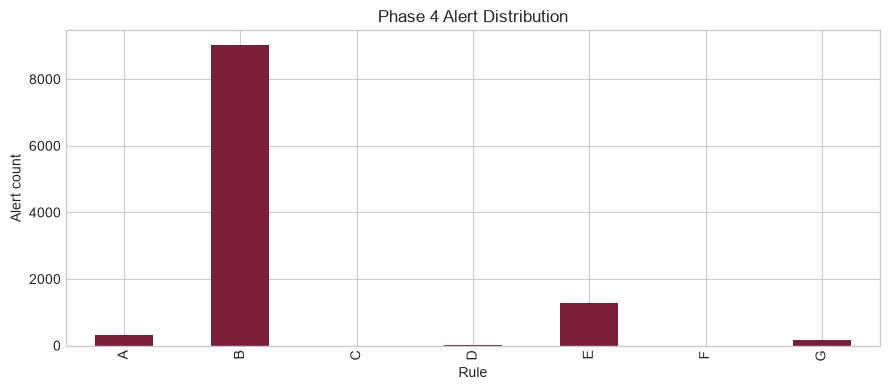

In [4]:
rule_names = {
    "A": "Benford's Law",
    "B": "Vendor Concentration",
    "C": "Duplicate Transactions",
    "D": "Round-Number Clustering",
    "E": "Frequency Outlier",
    "F": "Structuring",
    "G": "New Counterparty High Volume",
}
rule_counts = Counter(alert["rule"] for alert in alerts)
rule_distribution = pd.DataFrame(
    [
        {"rule": rule, "detection": rule_names[rule], "alerts": rule_counts.get(rule, 0)}
        for rule in "ABCDEFG"
    ]
)
display(rule_distribution)

ax = rule_distribution.plot.bar(x="rule", y="alerts", legend=False, figsize=(9, 4), color="#7b1e3a")
ax.set(title="Phase 4 Alert Distribution", xlabel="Rule", ylabel="Alert count")
plt.tight_layout()
plt.show()

## 6. Alerts by Branch

,branch,alerts
0,Rome,1608
1,Florence,1441
2,Venice,1318
3,London,1300
4,Milan,1285
5,Geneva,1284
6,Avignon,1282
7,Bruges,1264
8,Constance,1


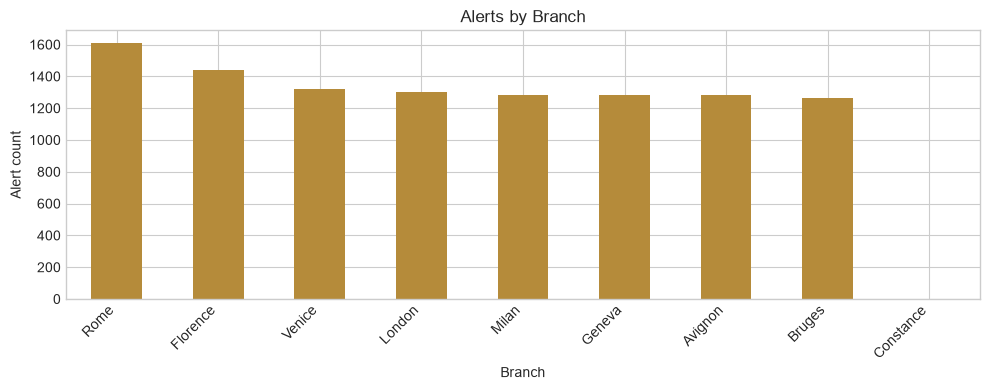

In [5]:
branch_counts = Counter(alert["branch"] for alert in alerts)
branch_alerts = pd.DataFrame(
    [{"branch": branch, "alerts": count} for branch, count in branch_counts.items()]
).sort_values(["alerts", "branch"], ascending=[False, True], ignore_index=True)
display(branch_alerts)

ax = branch_alerts.plot.bar(x="branch", y="alerts", legend=False, figsize=(10, 4), color="#b58b3a")
ax.set(title="Alerts by Branch", xlabel="Branch", ylabel="Alert count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Alerts by Counterparty

This direct alert-field view is descriptive only. It cannot support the final supplier ranking because branch-level rules may use `counterparty=None`.

In [6]:
counterparty_counts = Counter(alert["counterparty"] for alert in alerts)
counterparty_alerts = pd.DataFrame(
    [
        {"counterparty": counterparty if counterparty is not None else "<group-level>", "alerts": count}
        for counterparty, count in counterparty_counts.items()
    ]
).sort_values(["alerts", "counterparty"], ascending=[False, True], ignore_index=True)
display(counterparty_alerts.head(15))

,counterparty,alerts
0,London Operations,1144
1,Venice Operations,1137
2,Geneva Operations,1133
3,Milan Operations,1132
4,Rome Operations,1130
5,Avignon Operations,1120
6,Florence Operations,1111
7,Bruges Operations,1089
8,<group-level>,333
9,Silk Trader,67


## 8. Distinct Rules by Branch/Supplier

Each alert is joined to its underlying transactions through `affected_transaction_ids`. Only `operating_expense` transactions are eligible for the supplier ranking; this prevents depositors, borrowers, and customers from being mislabeled as vendors.

Ranking order:

1. Distinct rule count (descending)
2. Unique affected transaction count (descending)
3. Unique affected amount (descending)
4. Branch and supplier alphabetically (deterministic final tie-break)

Amounts are calculated once per unique transaction ID.

In [7]:
rules_by_supplier = defaultdict(set)
ids_by_supplier = defaultdict(set)

for alert in alerts:
    for transaction_id in alert["affected_transaction_ids"]:
        transaction = transactions_by_id[transaction_id]
        if transaction["type"] != "operating_expense":
            continue
        key = (transaction["branch"], transaction["counterparty"])
        rules_by_supplier[key].add(alert["rule"])
        ids_by_supplier[key].add(transaction_id)

ranking_rows = []
for (branch, supplier), rules in rules_by_supplier.items():
    unique_ids = ids_by_supplier[(branch, supplier)]
    total_amount = sum(
        (transactions_by_id[transaction_id]["debit_amount"] for transaction_id in unique_ids),
        Decimal("0"),
    )
    evidence = [transactions_by_id[transaction_id] for transaction_id in unique_ids]
    ranking_rows.append(
        {
            "branch": branch,
            "supplier": supplier,
            "distinct_rule_count": len(rules),
            "rules": ", ".join(sorted(rules)),
            "unique_transaction_count": len(unique_ids),
            "total_affected_amount": total_amount,
            "first_date": min(transaction["date"] for transaction in evidence),
            "last_date": max(transaction["date"] for transaction in evidence),
        }
    )

ranking_rows.sort(
    key=lambda row: (
        -row["distinct_rule_count"],
        -row["unique_transaction_count"],
        -row["total_affected_amount"],
        row["branch"],
        row["supplier"],
    )
)
ranking = pd.DataFrame(ranking_rows)
max_distinct_rules = ranking_rows[0]["distinct_rule_count"]
tied_leaders = ranking[ranking["distinct_rule_count"] == max_distinct_rules]

print(f"Suppliers tied at the maximum ({max_distinct_rules} rules): {len(tied_leaders)}")
display(ranking.head(15))

Suppliers tied at the maximum (3 rules): 2


,branch,supplier,distinct_rule_count,rules,unique_transaction_count,total_affected_amount,first_date,last_date
0,London,London Operations,3,"B, E, G",1397,4980223.97,1390-01-08,1440-12-27
1,Milan,Milan Operations,3,"B, D, E",1350,4752346.19,1390-02-11,1440-12-25
2,Venice,Venice Operations,2,"B, E",1356,5258258.74,1390-02-01,1440-12-29
3,Florence,Florence Operations,2,"B, E",1346,5165722.76,1390-01-19,1440-12-15
4,Rome,Rome Operations,2,"B, E",1342,4584441.84,1390-02-17,1440-12-07
5,Geneva,Geneva Operations,2,"B, E",1339,5176832.41,1390-01-16,1440-12-11
6,Avignon,Avignon Operations,2,"B, E",1314,5300482.27,1390-01-11,1440-12-30
7,Bruges,Bruges Operations,2,"B, E",1313,5558014.37,1390-01-05,1440-12-24
8,Florence,Ser Benedetto Forniture,2,"B, D",230,95610.0,1420-01-03,1424-12-26


## 9. Identify the Most Suspicious Activity

The formal winner follows the declared ranking. A high anomaly score is a lead for investigation, not proof of fraud.

In [8]:
winner = ranking_rows[0]
winner_key = (winner["branch"], winner["supplier"])
winner_rules = sorted(rules_by_supplier[winner_key])
winner_ids = ids_by_supplier[winner_key]

print(f"Branch: {winner['branch']}")
print(f"Supplier: {winner['supplier']}")
print(f"Distinct rules: {winner_rules}")
print(f"Unique affected transactions: {winner['unique_transaction_count']:,}")
print(f"Tie-break amount: {winner['total_affected_amount']:,} florins")

Branch: London
Supplier: London Operations
Distinct rules: ['B', 'E', 'G']
Unique affected transactions: 1,397
Tie-break amount: 4,980,223.97 florins


### Concentrated multi-rule secondary screen

The formal winner spans most of the 51-year dataset and may represent a recurring internal operating counterparty. As a secondary review—not a replacement for the required ranking—the analysis screens for suppliers flagged by at least two rules whose affected activity is confined to five years or less. This criterion is applied generically without naming a supplier in advance.

In [9]:
concentrated_candidates = []
for row in ranking_rows:
    duration_days = (row["last_date"] - row["first_date"]).days
    if row["distinct_rule_count"] >= 2 and duration_days <= 5 * 366:
        concentrated_candidates.append({**row, "duration_days": duration_days})

concentrated = pd.DataFrame(concentrated_candidates)
display(concentrated)
assert len(concentrated_candidates) == 1
secondary = concentrated_candidates[0]

,branch,supplier,distinct_rule_count,rules,unique_transaction_count,total_affected_amount,first_date,last_date,duration_days
0,Florence,Ser Benedetto Forniture,2,"B, D",230,95610.0,1420-01-03,1424-12-26,1819


## 10. Retrieve Affected Transactions

The final evidence set intersects alert IDs with the winning branch and supplier, then deduplicates by transaction ID.

In [10]:
winner_transactions = sorted(
    (transactions_by_id[transaction_id] for transaction_id in winner_ids),
    key=lambda transaction: (transaction["date"], transaction["id"]),
)
assert len({transaction["id"] for transaction in winner_transactions}) == len(winner_transactions)
assert all(
    transaction["branch"] == winner["branch"]
    and transaction["counterparty"] == winner["supplier"]
    and transaction["type"] == "operating_expense"
    for transaction in winner_transactions
)

evidence_table = pd.DataFrame(
    [
        {
            "id": transaction["id"],
            "date": transaction["date"],
            "branch": transaction["branch"],
            "supplier": transaction["counterparty"],
            "category": transaction["debit_account"],
            "amount": transaction["debit_amount"],
        }
        for transaction in winner_transactions
    ]
)
display(evidence_table.head(10))
print(f"Evidence rows retained: {len(evidence_table):,}")

,id,date,branch,supplier,category,amount
0,31,1390-01-08,London,London Operations,Rent,2618.86
1,45,1390-01-13,London,London Operations,Maintenance,1515.97
2,67,1390-01-18,London,London Operations,Maintenance,352.84
3,82,1390-01-21,London,London Operations,Wages,17307.53
4,115,1390-01-29,London,London Operations,Wages,8694.48
5,137,1390-02-03,London,London Operations,Supplies,40.37
6,270,1390-03-05,London,London Operations,Security,1621.86
7,333,1390-03-20,London,London Operations,Courier Services,58.3
8,413,1390-04-05,London,London Operations,Courier Services,77.05
9,502,1390-04-29,London,London Operations,Courier Services,366.18


Evidence rows retained: 1,397


## 11. Determine Date Range

In [11]:
first_suspicious_date = min(transaction["date"] for transaction in winner_transactions)
last_suspicious_date = max(transaction["date"] for transaction in winner_transactions)
print(f"First affected transaction: {first_suspicious_date}")
print(f"Last affected transaction:  {last_suspicious_date}")

First affected transaction: 1390-01-08
Last affected transaction:  1440-12-27


## 12. Calculate Transaction Count and Total Amount

In [12]:
suspicious_transaction_count = len(winner_transactions)
total_suspected_amount = sum(
    (transaction["debit_amount"] for transaction in winner_transactions),
    Decimal("0"),
)
average_suspicious_amount = total_suspected_amount / suspicious_transaction_count

assert suspicious_transaction_count == winner["unique_transaction_count"]
assert total_suspected_amount == winner["total_affected_amount"]

print(f"Unique transaction count: {suspicious_transaction_count:,}")
print(f"Total affected amount:    {total_suspected_amount:,.2f} florins")
print(f"Average transaction:      {average_suspicious_amount:,.2f} florins")

Unique transaction count: 1,397
Total affected amount:    4,980,223.97 florins
Average transaction:      3,564.94 florins


## 13. Detection Methods

In [13]:
rule_evidence = []
for rule in winner_rules:
    rule_ids = {
        transaction_id
        for alert in alerts
        if alert["rule"] == rule
        for transaction_id in alert["affected_transaction_ids"]
        if transaction_id in winner_ids
    }
    descriptions = [
        alert["description"]
        for alert in alerts
        if alert["rule"] == rule
        and any(transaction_id in winner_ids for transaction_id in alert["affected_transaction_ids"])
    ]
    rule_evidence.append(
        {
            "rule": rule,
            "method": rule_names[rule],
            "unique_winner_transactions": len(rule_ids),
            "example_alert_description": descriptions[0] if descriptions else "",
        }
    )
rule_evidence_table = pd.DataFrame(rule_evidence)
display(rule_evidence_table)

,rule,method,unique_winner_transactions,example_alert_description
0,B,Vendor Concentration,1397,London Operations represents 100.00% of Rent expenses.
1,E,Frequency Outlier,72,"London Operations had 9 operating_expense transactions in 1390-08, exceeding the frequency thres..."
2,G,New Counterparty High Volume,5,New counterparty London Operations had 5 transactions totaling 30489.68 during its first active ...


## 14. Findings

### Primary ranking result

The alert-led ranking identifies **London / London Operations**. It is associated with Rules **B, E, and G**, covers **1,397 unique operating-expense transactions**, spans **1390-01-08 through 1440-12-27**, and totals **4,980,223.97 florins**. Rule B affects the full evidence set, while Rules E and G identify smaller frequency and first-period subsets.

This is a broad 51-year operating relationship. Its scale and multi-rule exposure justify review, but the name and duration are also consistent with a recurring internal branch-operations counterparty. The evidence supports an investigation lead—not a conclusion that fraud occurred.

### Concentrated secondary finding

The generic five-year concentration screen identifies exactly one supplier: **Florence / Ser Benedetto Forniture**. It is flagged by Rules **B and D**, contains **230 unique transactions**, spans **1420-01-03 through 1424-12-26**, and totals **95,610.00 florins**. This shorter, concentrated pattern warrants focused vendor-verification and payment-authorization review even though it does not win the formal distinct-rule ranking.

## 15. Recommended Internal Controls

1. **Independent vendor onboarding and periodic reverification.** Require legal identity, ownership, address, tax or guild documentation, bank-account verification, and conflict-of-interest checks by staff who cannot approve invoices. Reverify high-concentration suppliers annually.
2. **Segregated purchase, receipt, and payment approval.** Different employees should authorize the purchase, confirm delivery, and release payment. Require secondary approval when cumulative supplier spend or payment frequency exceeds branch-specific limits.
3. **Monthly supplier-concentration and frequency review.** Present branch managers and internal audit with vendor share, transaction count, round-number rate, and new-vendor volume, including explanations and sign-off for exceptions.
4. **Independent reconciliation and evidence retention.** Match invoices, purchase orders, receiving evidence, and ledger entries; retain the documentation and periodically sample high-risk suppliers for audit.

For London Operations, management should first establish whether the counterparty represents an internal clearing label. If so, replace the generic label with accountable cost centers and named approvers so monitoring does not combine unrelated activity.

## 16. Conclusion

The full 80,230-transaction ledger and all 10,783 Phase 4 alerts were analyzed without rebuilding anomaly logic. The formal distinct-rule ranking identifies London Operations, while a transparent concentrated-episode screen surfaces Ser Benedetto Forniture as a secondary high-priority review. Both findings require documentary follow-up; anomaly alerts alone do not prove fraud. The recommended controls focus on vendor legitimacy, approval separation, continuous supplier monitoring, and independent reconciliation.